### Measurement
Measurement begins with recording the ISSW-measured intensity of light when a filter paper contains LAI (for *light-absorbing impurity*), and $I_0$ when a filter is clean (see Eq. 1 of Grenfell et al, 2011, Eq. 1). Then the *absorption optical depth* is given by

$$
\chi_\lambda = log({I_0 \over I}) \ \ \ (1)
$$

where Here, we'll focus on $\lambda_1=450 \ nm$ and $\lambda_2=600 \ nm$). We can use the absorption optical depth to compute an *instrumental optical depth*, $f_{instr}$, according to a version (the inverse) of Grenfell et al's Eq. 4,

$$
f_{instr}(R_\lambda,\chi_\lambda) = {1\over2}ln \bigl( (1-R_\lambda) \times exp(\chi_\lambda)+((1-R_\lambda)^2 \times exp(2\chi_\lambda)+4R_\lambda) \bigr) \ \ \ (2)
$$

where $R_\lambda \equiv R_1R_2(\lambda)$ is the wavelength-dependent product of reflectivities of the two integrating spheres of the ISSW; other instrument-specific parameters are the size of the ISSW aperture and the intensity of the light source. Properties of the millipore filter paper itself also affect $f_{instr}$. We account for these effects via the factor $\kappa_\lambda$,

$$
\tau_\lambda  = f_{instr} \times \kappa_\lambda \ \ \ (3)
$$

Values of $\kappa_\lambda$ and $R_\lambda$ must be determined by a calibration procedure (described below). Once known, however, we can compute the LAI loading, 

$$
L_{ISSW} = {\tau_\lambda \over \beta_{\lambda,std}}  \ \ \ (4)
$$

where $\beta_{\lambda,std}$ is the *mass absorption cross section*, also referred to as *MAC*, of a standard LAI. For a fullerene standard, these values are $\beta_{450,fullerene}=8.9 \ m^2/g$ and $\beta_{600,fullerene}=6.5 \ m^2/g$, consistent with $Å=1.09$. We can also use ratios of optical depths produced by Eq. 3 to calculate an LAI's's *absorption Angstrom exponent*,

$$
Å = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})} \ \ \ (5)
$$

where (because of the proportionality in Eq. 3) we could also use $-{log(\tau'_{450}/\tau'_{600}) \over log(\lambda_{450}/\lambda_{600})}$ to achieve the same result.

### Calibration
The goal of calibration is to obtain values of $R_{450}$, $R_{600}$, $\kappa_{450}$ and $\kappa_{600}$. The process relies on ISSW-measured intensities ($I$) of a set of filter papers with varying loadings ($L_{ISSW}$) of a standard LAI (fullerene) ... that minimize the sum of squared differences between $\tau_\lambda$(obs) and $\tau_\lambda$(theory). We'll need the inverse of Eq. 2 (which is Grenfell et al's Eq. 4),

$$
\chi_\lambda = 2 f_\lambda + ln \bigl ({1 - R e^{-4 f_\lambda}   \over 1 - R}    \bigr ) \ \ \ (6)
$$

... We should note that this procedure also takes into account a difference in units, namely, that $L_{ISSW}$ has units ${\mu g \over cm^2}$, while $L_{LAHM}$ has units $\mu g$.


**References**

Grenfell, T. C., Doherty, S. J., Clarke, A. D., & Warren, S. G. (2011). Light absorption from particulate impurities in snow and ice determined by spectrophotometric analysis of filters. Applied Optics, 50(14), 2037-2048.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from importlib import reload  # Python 3.4+
import ISSWlib as IS; reload(IS)
%matplotlib inline

### Fullerene standard on millipore filters

In [2]:
# Load the standard ISSW spectra
spectrum_folder = 'Ulyana ful/'
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  Ulyana ful/spectrum_files.txt , finding these spectra:
      2 ug.txt
      5 ug.txt
      10 ug.txt
      25 ug.txt
      40 ug.txt
      66 ug.txt


lambda_450 =  450.0
lambda_600 =  600.0
[0.36342949 0.74688788 1.4248183  1.80884811]
[0.29156555 0.73696378 1.52024991 2.75499862]
Length of L_range =  4
Number of loadings =  4


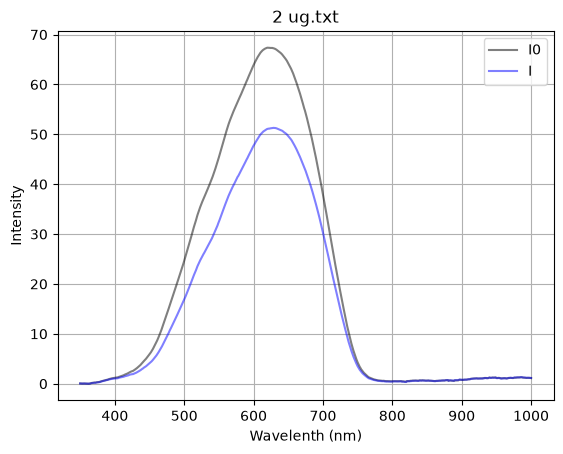

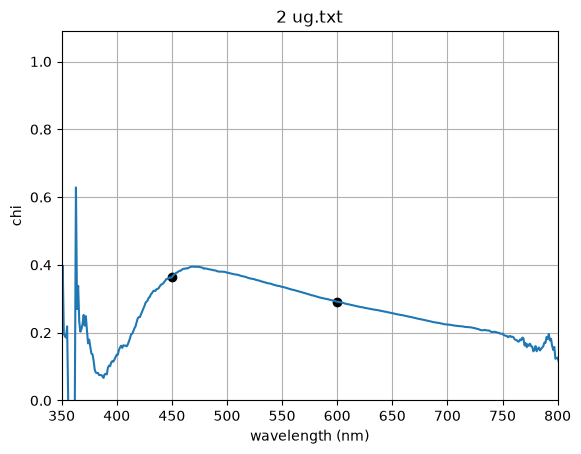

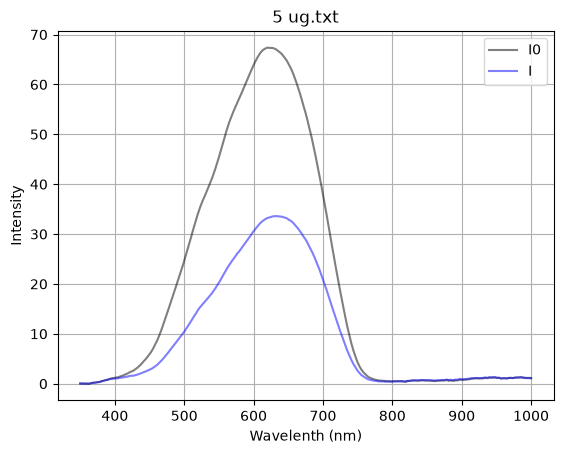

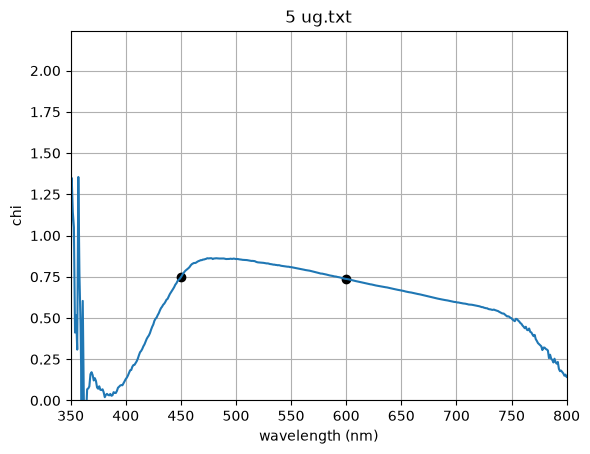

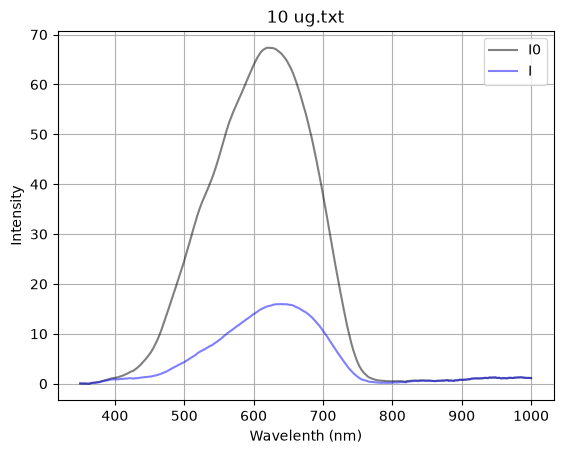

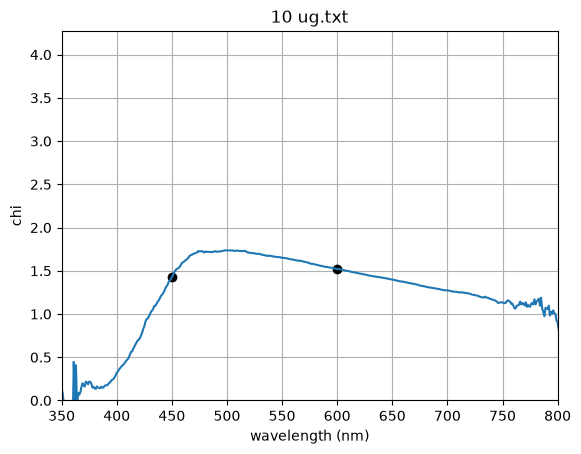

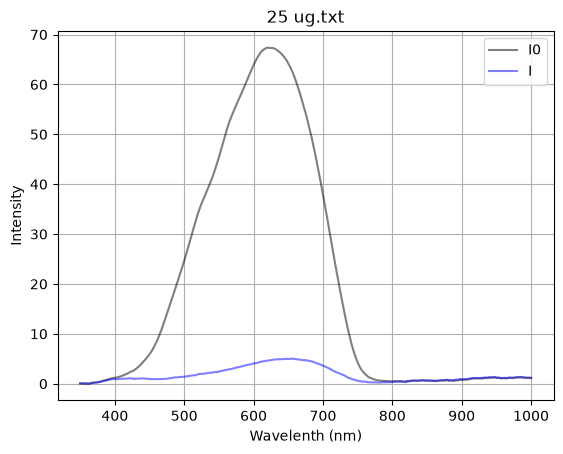

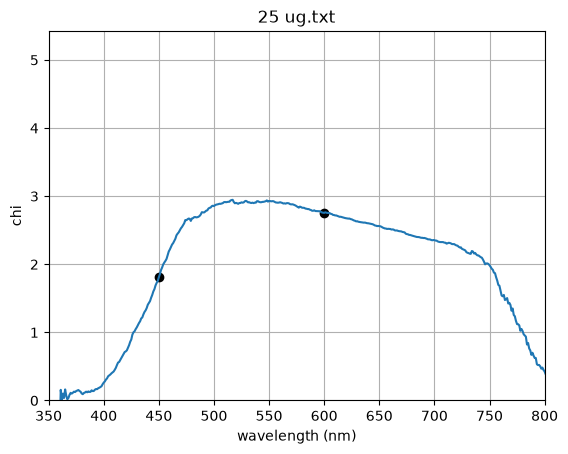

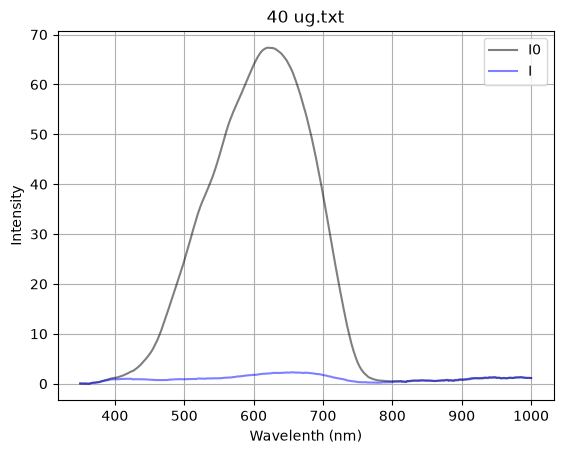

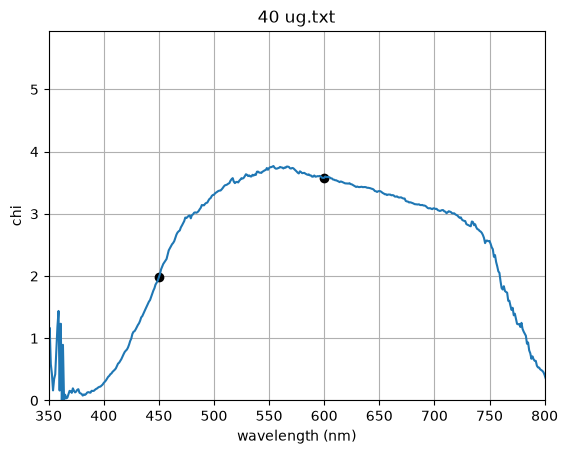

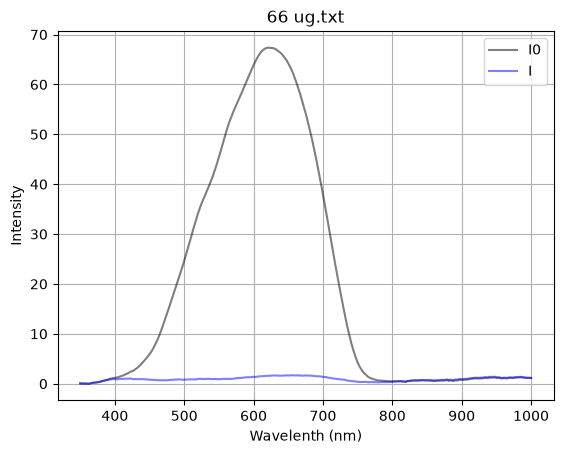

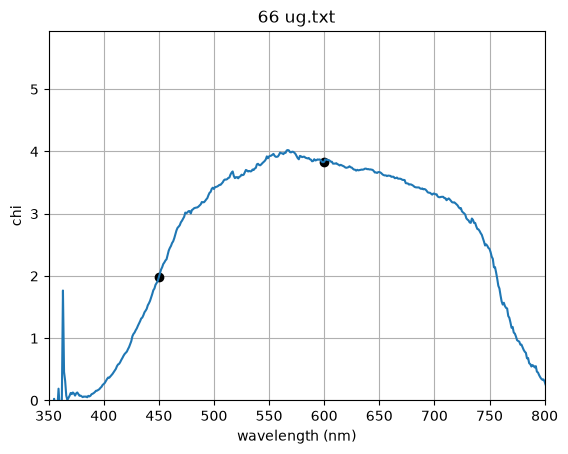

In [3]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])

# Preallocate arrays
# chi_observed = np.zeros((number_of_loadings,2))
chi_range_450 = np.zeros(number_of_loadings)
chi_range_600 = np.zeros(number_of_loadings)

# Get the chi-values
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get observed chi
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    
    # Save chi values at lambda1 and lambda2
    chi_range_450[i] = chi[I_450]
    chi_range_600[i] = chi[I_600]

# Specify subsets of the calibration dataset to use (set to 0 and -1 for all)
subset_start = 0
subset_stop = -2
chi_range_450 = chi_range_450[subset_start:subset_stop]; print(chi_range_450)
chi_range_600 = chi_range_600[subset_start:subset_stop]; print(chi_range_600)
number_of_loadings = np.size(chi_range_450)

# Loading values on samples and their optical depths
L_range = np.array([2, 5, 10, 25, 40, 66])/2 # This is in micrograms
L_range = L_range[subset_start:subset_stop]

# Double-checking
print('Length of L_range = ', len(L_range))
print('Number of loadings = ', number_of_loadings)
if len(L_range) != number_of_loadings:
    print('inconsistency')
    np.sqrt(-1)

### Using Tom's theory
The cell below uses Tom's formulas.

In [4]:
# Specify beta1 
Iwantcustombeta1 = True
if Iwantcustombeta1:
    beta_std_450 = 2 # This is in m^2/g, for 450
else:
    beta_std_450 = 8.9 
beta1_std = beta_std_450 / 100 # Puts it cm^2/ug

# Flag for getting AAE from slopes of chi
IwantAAE_from_slopes = True

# Preparation for getting the optimal values of R1R2, kappa, and AAE
niter_for_B_ratio = 1 # Sadly, this doesn't converge, so sticking with 1 iteration
dchi_dL_450 = np.diff(chi_range_450)/np.diff(L_range)
dchi_dL_600 = np.diff(chi_range_600)/np.diff(L_range)

# Specify starting values of R1R2 and kappa
R1R2_450 = 0.5
R1R2_600 = 0.5
kappa_450 = 1
kappa_600 = 1

# Get optimal values of R1R2, kappa, and AAE
for i in range(niter_for_B_ratio):
    print('\nLooking for optimal values of R1R2, kappa, and AAE ...')

    if IwantAAE_from_slopes:

        # This formula assumes kappa and B-values are different for the two frequencies (except 1st time through the loop)
        top = dchi_dL_450 *kappa_450 *IS.get_B(R1R2_450)
        bot = dchi_dL_600 *kappa_600 *IS.get_B(R1R2_600)
        
        # Get the revised beta2
        AAE_std = (-np.log(top/bot)/np.log(450/600))[0]
        print('AAE_std from chi slopes = ', AAE_std)
        beta2_std = beta1_std * (450/600)**AAE_std
        beta_std_600 = beta2_std * 100
        print('beta2 from AAE = ', beta_std_600, 'm^2/g')

        # Calculating the known optical depth based on these loadings and betas
        tau_range_450 = L_range*beta1_std
        tau_range_600 = L_range*beta2_std
    
    else:
        
        AAE_std = 1.09
        print('Using a specified AAE = ', AAE_std)
        
    R1R2_450, kappa_450 = IS.get_R1R2_and_kappa(chi_range_450,tau_range_450,R1R2_450,verbose=False)
    print('450: I get R1R2, kappa = ', R1R2_450, kappa_450)
    R1R2_600, kappa_600 = IS.get_R1R2_and_kappa(chi_range_600,tau_range_600,R1R2_600,verbose=False)
    print('600: I get R1R2, kappa = ', R1R2_600, kappa_600)


Looking for optimal values of R1R2, kappa, and AAE ...
AAE_std from chi slopes =  -0.5204970729206022
beta2 from AAE =  2.323059012881579 m^2/g
450: I get R1R2, kappa =  0.8388271945671792 1.0420298423054875
600: I get R1R2, kappa =  0.1556148230299873 0.20506113145351412


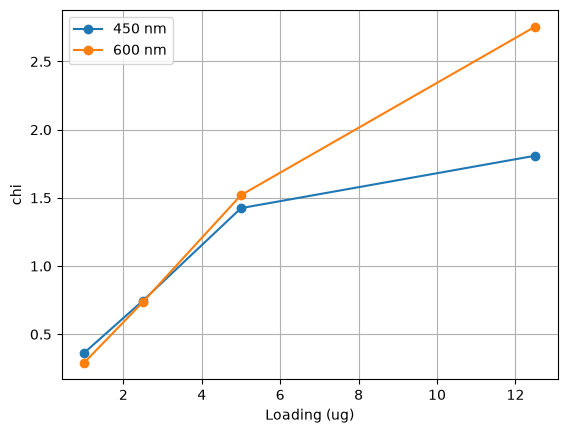

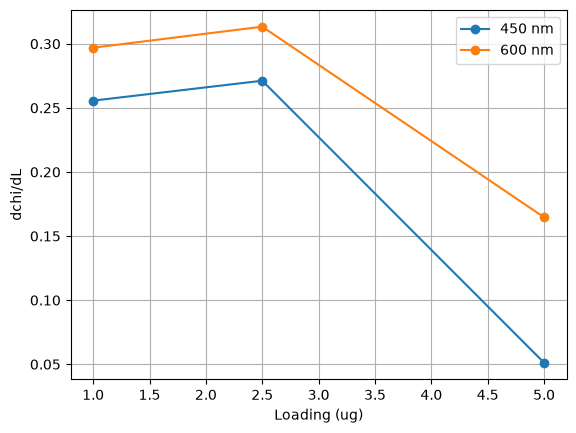

In [6]:
# Let's take a look at chi as a function of loading
plt.figure()
plt.plot(L_range,chi_range_450,marker='o',label='450 nm')
plt.plot(L_range,chi_range_600,marker='o',label='600 nm')
plt.xlabel('Loading (ug)')
plt.ylabel('chi')
plt.legend()
plt.grid(True)


# Let's take a look at dchi/dL as a function of loading
plt.figure()
plt.plot(L_range[0:-1],dchi_dL_450,marker='o',label='450 nm')
plt.plot(L_range[0:-1],dchi_dL_600,marker='o',label='600 nm')
plt.xlabel('Loading (ug)')
plt.ylabel('dchi/dL')
plt.legend()
plt.grid(True)

Equivalent loadings from chi, theory values
For obs,  2 ug.txt  %deviations = 0.12419463782468664 1.7563728249573062e-11
For obs,  5 ug.txt  %deviations = -0.8266553306792258 -7.8111043602069845
For obs,  10 ug.txt  %deviations = -28.966400711543468 -16.785714091034237
For obs,  25 ug.txt  %deviations = 12.581472364880897 9.487647607806613


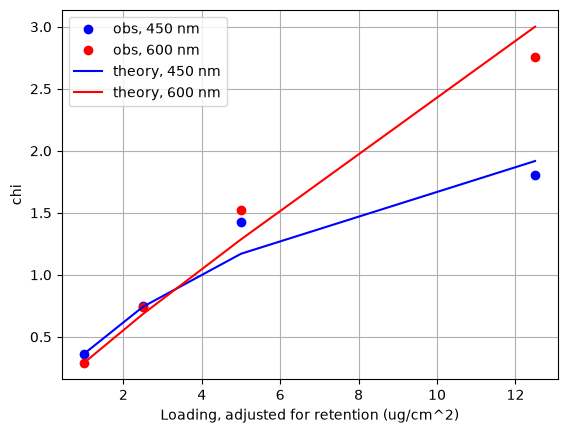

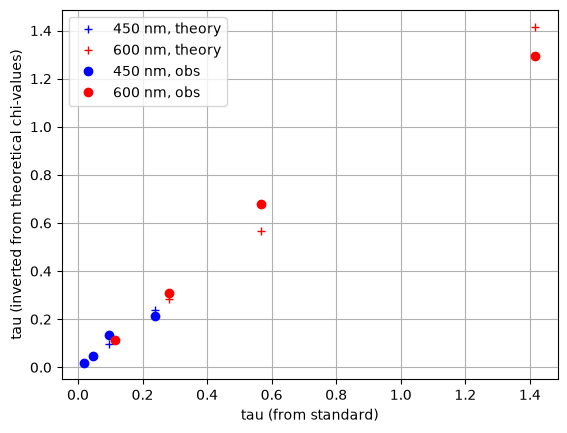

In [6]:
IS.other_diagnostics(L_range,beta1_std,kappa_450,beta2_std,kappa_600,R1R2_450,R1R2_600,chi_range_450,chi_range_600,spectrum_list)

In [7]:
# Saving parameters
# parameter_filename = 'calibration parameters from Ulyana ful (July 16, 2026), with iterative adj of AAE.csv'
parameter_filename = 'calibration parameters from Ulyana ful (July 16, 2026).csv'
calibration_spectrum_folder = spectrum_folder
Save_parameter_flag = False
if Save_parameter_flag:
    print('Saving the parameter file ...')
    data = {
    "calibration_spectrum_folder": [calibration_spectrum_folder],
    "kappa_450": [kappa_450],
    "kappa_600": [kappa_600],
    "R1R2_450": [R1R2_450],
    "R1R2_600": [R1R2_600],
    "beta_std_450": [beta_std_450],
    "beta_std_600": [beta_std_600],
    "AAE_std": [AAE_std]
    }
    df = pd.DataFrame(data)
    
    # Display the DataFrame
    print(df)

    df.to_csv(parameter_filename, index=False)